In [2]:
import casatools

In [3]:
from casatools import ms as mstool
ms = mstool()

In [4]:
import pylab as pl
import numpy as np

# W51 2017.1.00293.S

In [5]:
ms.open('/orange/adamginsburg/w51/2017.1.00293.S/may2021_imaging/calibrated_final_cont.ms')
ms.selectinit(6)
ms.selectchannel(start=0, nchan=1)
ms.selectpolarization('XX')
ms.select({'uvdist': [0.1, 1e10]}) 
uv = ms.getdata(['u','v'])
ms.close()
print(uv['u'].size)

1116900


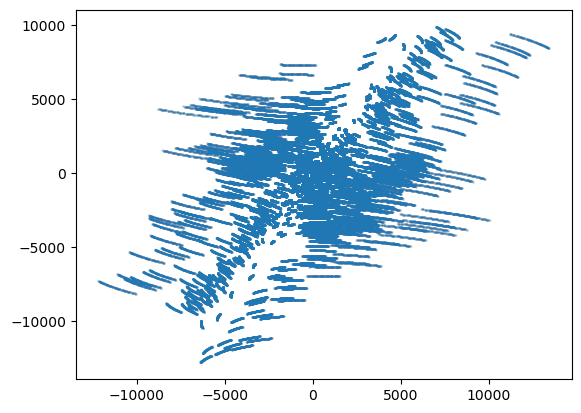

In [6]:
pl.scatter(uv['u'], uv['v'], s=1, alpha=0.02)

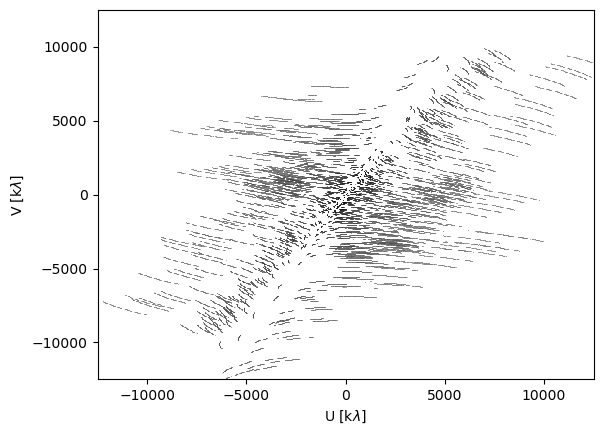

In [70]:
hist, lx, ly, _ = pl.hist2d(uv['u'], uv['v'],
          norm=pl.matplotlib.colors.AsinhNorm(),
                            cmap='gray_r',
          bins=[np.linspace(-12500, 12500, 513), np.linspace(-12500, 12500, 513)]);
#pl.colorbar();
pl.xlabel("U [k$\lambda$]")
pl.ylabel("V [k$\lambda$]");

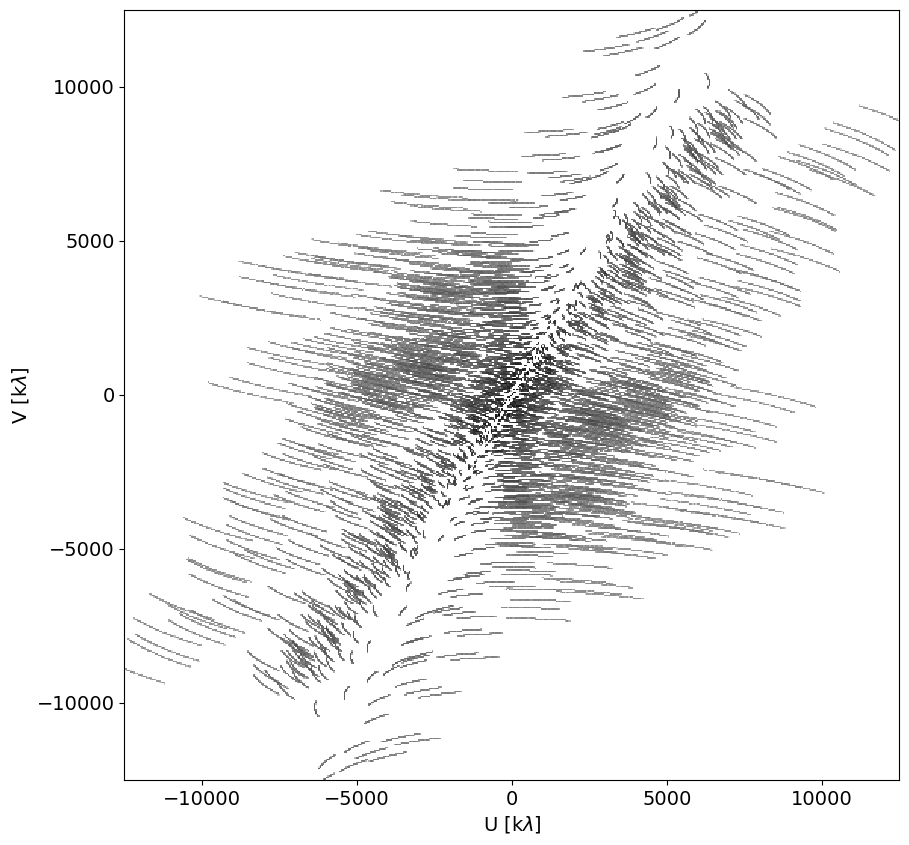

In [107]:
pl.rcParams['font.size'] = 14
pl.figure(figsize=(10,10))
hist, lx, ly, _ = pl.hist2d(np.concatenate([uv['u'], -uv['u']]),
                            np.concatenate([uv['v'], -uv['v']]),
          norm=pl.matplotlib.colors.AsinhNorm(),
                            cmap='gray_r',
          bins=[np.linspace(-12500, 12500, 513), np.linspace(-12500, 12500, 513)]);
#pl.colorbar();
pl.xlabel("U [k$\lambda$]")
pl.ylabel("V [k$\lambda$]");
pl.savefig("W51_UVCoverage.png", bbox_inches='tight')
pl.savefig("W51_UVCoverage.pdf", bbox_inches='tight')

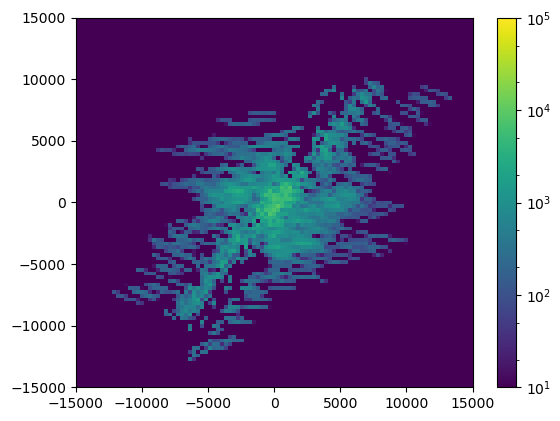

In [7]:
pl.hist2d(uv['u'], uv['v'],
          norm=pl.matplotlib.colors.AsinhNorm(vmax=1e5, vmin=10),
          bins=[np.linspace(-15000, 15000, 100), np.linspace(-15000, 15000, 100)]);
pl.colorbar();

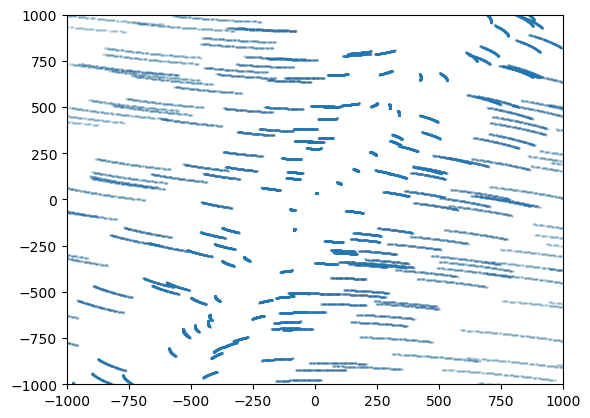

In [8]:
pl.scatter(uv['u'], uv['v'], s=1, alpha=0.02)
pl.axis([-1000, 1000, -1000, 1000]);

# Orion 2016.1.00165.S

In [9]:
ms.open('/orange/adamginsburg/orion/2016.1.00165.S/measurement_sets/B6_calibrated_final_cont.ms')
#summary = ms.summary()
ms.selectinit(6)
ms.selectchannel(start=25, nchan=1)
ms.selectpolarization('XX')
ms.select({'uvdist': [0.1, 1e10]}) 
uv2 = ms.getdata(['u','v','data'])
ms.close()
print(uv2['u'].size)
#print(summary)

749070


## Basic gridded imaging

In [84]:
bins = 1024
uv_minmax = max([np.max(np.abs(uv2['u'])), np.max(np.abs(uv2['v']))])
gridded_real, uu, vv = np.histogram2d(uv2['u'], uv2['v'],
                              weights=uv2['data'].real.squeeze(),
                              bins=[np.linspace(-uv_minmax, uv_minmax, bins + 1), np.linspace(-uv_minmax, uv_minmax, bins + 1)]);
gridded_imag, uu, vv = np.histogram2d(uv2['u'], uv2['v'],
                              weights=uv2['data'].imag.squeeze(),
                              bins=[np.linspace(-uv_minmax, uv_minmax, bins + 1), np.linspace(-uv_minmax, uv_minmax, bins + 1)]);
uu = np.linspace(-uv_minmax, uv_minmax, bins)
gridded = gridded_real + gridded_imag*1j

# UV = VU
gridded += np.conjugate(gridded[::-1, ::-1])

In [85]:
(gridded != 0).sum(), (np.abs(gridded) > 1).sum()

(39836, 28864)

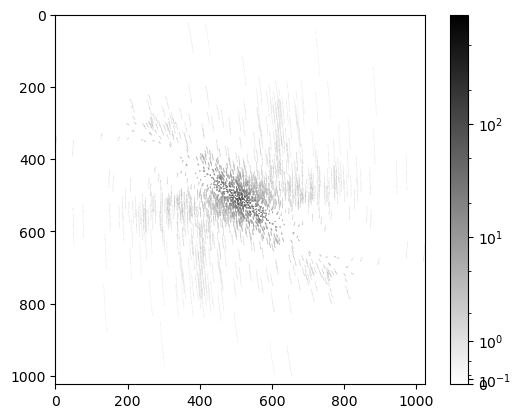

In [86]:
pl.imshow(np.abs(gridded),
          norm=pl.matplotlib.colors.AsinhNorm(),
          cmap='gray_r',
         );
pl.colorbar();

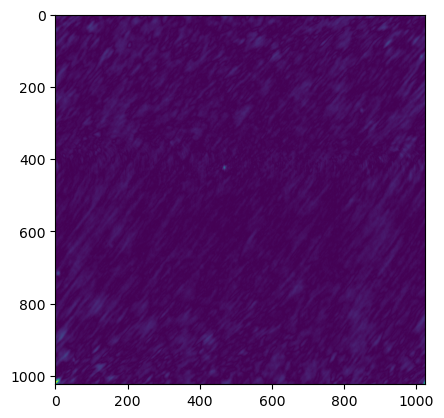

In [87]:
#pl.imshow(gridded_real, norm=pl.matplotlib.colors.AsinhNorm(vmax=0.1))
pl.imshow(np.abs(np.fft.ifft2(np.fft.fftshift(gridded))), norm=pl.matplotlib.colors.AsinhNorm());

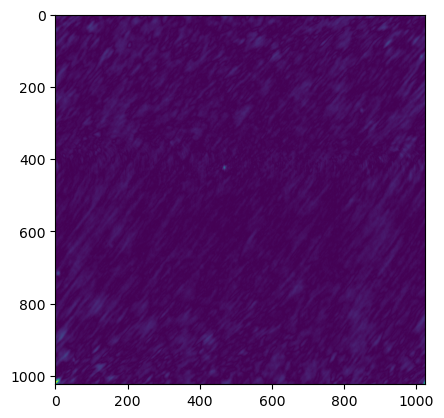

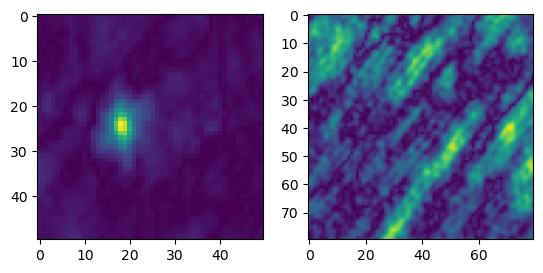

In [88]:
img = np.abs(np.fft.ifft2(np.fft.fftshift(gridded)))
pl.imshow(img, norm=pl.matplotlib.colors.AsinhNorm());
pl.figure()
# for 2048
#pl.subplot(1,2,1).imshow(img[350:500, 1400:1550]);
#pl.subplot(1,2,2).imshow(img[1000:1050, 1000:1050]);
pl.subplot(1,2,1).imshow(img[400:450, 450:500]);
dx = 40
pl.subplot(1,2,2).imshow(img[512-dx:512+dx, 512-dx:512+dx]);

### KRISP

In [15]:
from sklearn.gaussian_process import GaussianProcessRegressor      # to run the kernel methods
from sklearn.gaussian_process.kernels import Matern                # for the Matern kernel

In [16]:
kernel = Matern(length_scale=4.4, nu=1.5)

In [17]:
gridded.shape

(1024, 1024)

In [18]:
uw, vw = np.where(gridded != 0)
points_list = np.c_[uu[uw], uu[vw]]
vis_points = gridded[gridded != 0]
std_deviation = np.std(vis_points)
dsfac = 5
len(vis_points)

20625

In [19]:
clf_real = GaussianProcessRegressor(kernel=kernel, alpha=std_deviation**2.)
clf_real.fit(points_list[::dsfac], np.real(vis_points)[::dsfac])

GaussianProcessRegressor(alpha=263.135151374237,
                         kernel=Matern(length_scale=4.4, nu=1.5))

In [20]:
clf_imag = GaussianProcessRegressor(kernel=kernel, alpha=std_deviation**2.)  
clf_imag.fit(points_list[::dsfac], np.imag(vis_points)[::dsfac])

GaussianProcessRegressor(alpha=263.135151374237,
                         kernel=Matern(length_scale=4.4, nu=1.5))

In [21]:
dist = (points_list**2).sum(axis=1)**0.5
(dist > 2000).sum()

16237

In [54]:
from tqdm.auto import tqdm

In [66]:
U, V = np.meshgrid(uu, uu)
Z_recon = np.zeros_like(gridded)

for ii, (Urow, Vrow) in tqdm(enumerate(zip(U, V))):
    prediction_points = np.c_[Urow.ravel(), Vrow.ravel()]
    
    z_recon_real = clf_real.predict(prediction_points, return_std=False)
    
    Z_recon[:, ii].real = z_recon_real

    z_recon_imag = clf_imag.predict(prediction_points, return_std=False)
    
    Z_recon[:, ii].imag = z_recon_imag


(1024, 2)


0it [00:00, ?it/s]

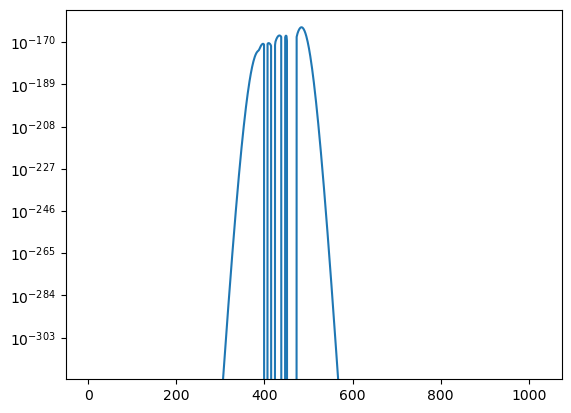

In [67]:
pl.semilogy(z_recon_real)

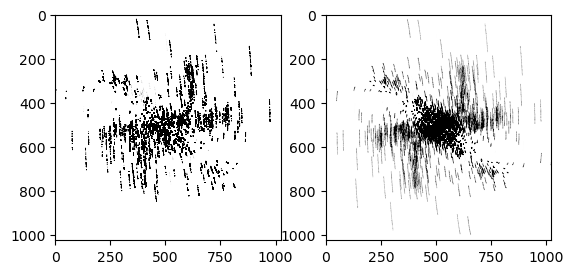

In [100]:
pl.subplot(1,2,1).imshow(np.abs(Z_recon), norm=pl.matplotlib.colors.AsinhNorm(vmax=0.0001), 
          cmap='gray_r',
                        );
pl.subplot(1,2,2).imshow(np.abs(gridded),
          norm=pl.matplotlib.colors.AsinhNorm(vmax=1),
          cmap='gray_r',
         );

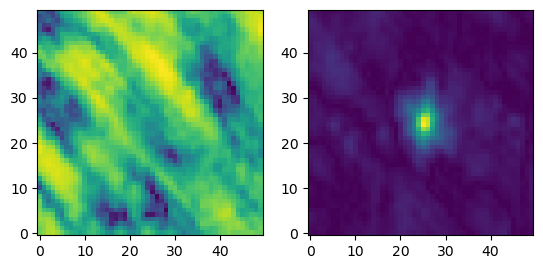

In [101]:
dx = 50
slc = slice(400,450), slice(443,493)
reconstructed = np.abs(np.fft.fftshift(np.fft.fft2(Z_recon)))
pl.subplot(1,2,1).imshow(reconstructed[slc], norm=pl.matplotlib.colors.AsinhNorm(), origin='lower')
pl.subplot(1,2,2).imshow(img[slc], norm=pl.matplotlib.colors.AsinhNorm(), origin='lower')

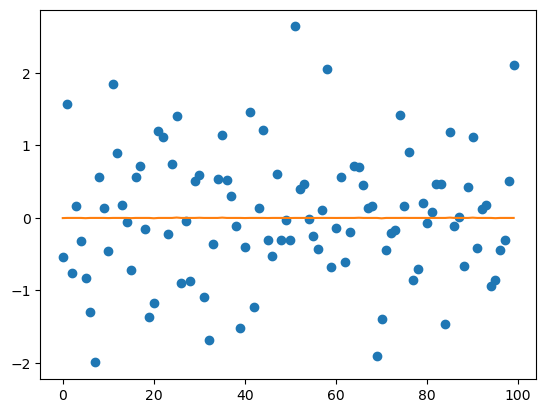

In [59]:
pl.plot(vis_points.imag[:100], 'o')
pl.plot(clf_imag.predict(points_list[:100, :]), '-')
#clf_real.predict([[10, -100]])

### Tinygp

In [111]:
import tinygp
import jax.numpy as jnp

In [114]:
kernel_tgp = tinygp.kernels.Matern32(scale=4.4)
clf_real_tgp = tinygp.GaussianProcess(kernel=kernel_tgp, X=np.array(points_list), diag=std_deviation**2)

clf_real_tgp_fitted = clf_real_tgp.condition(np.real(vis_points), points_list)

clf_real_tgp_fitted

ValueError: std::bad_cast

## Nearest Neighbor analysis

In [259]:
from scipy.spatial import KDTree

In [260]:
data = np.array([uv2['u'], uv2['v']]).T
dist = (data**2).sum(axis=1)**0.5

# avoid autocorr
data = data[dist > 0]
dist = dist[dist > 0]

kdtr = KDTree(data)

#q = KDTree(data).query(data)
#q

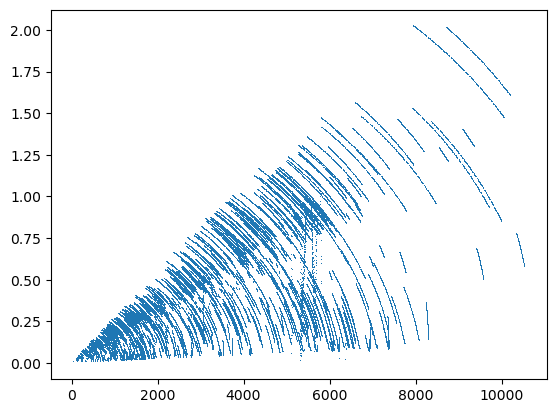

In [261]:
seps, inds = kdtr.query(data, k=[2])
pl.plot(dist, seps, ',');

In [262]:
data.size, data.shape, (dist > 1000).sum(), (dist>2000).sum()

(1498140, (749070, 2), 580527, 376955)

## Nearest Island

In [263]:
from scipy import ndimage

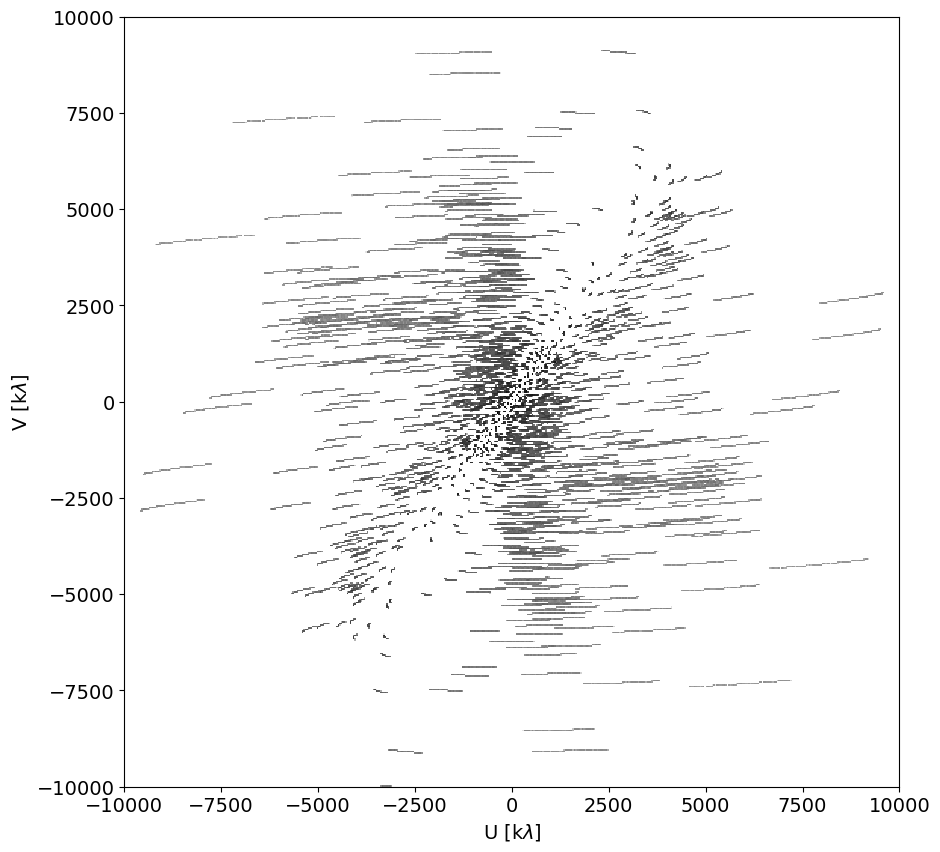

In [108]:
pl.rcParams['font.size'] = 14
pl.figure(figsize=(10,10))
hist, lx, ly, _ = pl.hist2d(np.concatenate([uv2['u'], -uv2['u']]),
                            np.concatenate([uv2['v'], -uv2['v']]),
          norm=pl.matplotlib.colors.AsinhNorm(),
                            cmap='gray_r',
          bins=[np.linspace(-10000, 10000, 513), np.linspace(-10000, 10000, 513)]);
#pl.colorbar();
pl.xlabel("U [k$\lambda$]")
pl.ylabel("V [k$\lambda$]");

pl.savefig("Orion_UVCoverage.png", bbox_inches='tight')
pl.savefig("Orion_UVCoverage.pdf", bbox_inches='tight')

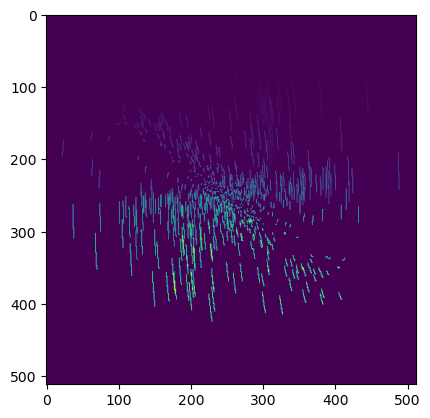

In [280]:
pl.imshow(labels)

nlabels = 477


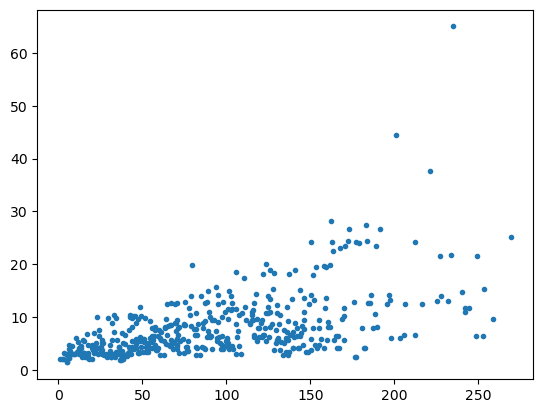

In [281]:
labels, nlabels = ndimage.label(hist)
print(f'nlabels = {nlabels}')
objs = ndimage.find_objects(labels)
centroids = np.array(ndimage.center_of_mass(hist, labels, index=np.arange(nlabels)))
# label 0 is zeros
kdtr = KDTree(centroids[1:])
neighbor_sep, _ = kdtr.query(centroids[1:], [2])
dist = ((centroids[1:]-256)**2).sum(axis=1)**0.5
pl.plot(dist, neighbor_sep, '.');

## Simulated Reimaging

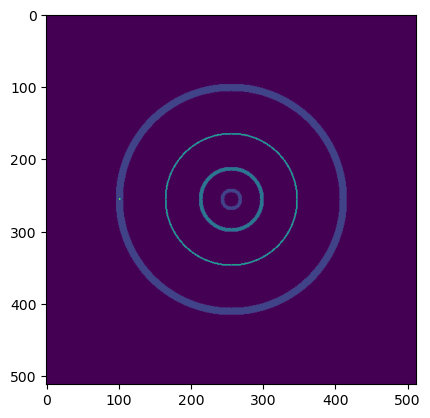

In [171]:
from turbustat.simulator.gen_field import make_extended
imsize = 512
powerlaw = 3
im = make_extended(imsize=imsize, powerlaw=powerlaw, randomseed=0)
# the real sky is positive, so we subtract the minimum to force the overall image positive
im = im - im.min()
largest_scale = 100
smallest_scale = 1
ygrid, xgrid = np.indices(im.shape, dtype='float')
rr = ((xgrid-im.shape[1]/2)**2+(ygrid-im.shape[0]/2)**2)**0.5
az = np.arctan2((xgrid-im.shape[1]/2), (ygrid-im.shape[0]/2))
pixscale=1
image_scale = im.shape[0]*pixscale # assume symmetric (default=256)
ring = (rr>=(image_scale/largest_scale)) & (rr<=(image_scale/smallest_scale))
ring_model = np.zeros(im.shape)
ring_model[(rr > 10) & (rr < 15)] = 1
ring_model[(rr > 40) & (rr < 45)] = 2
ring_model[(rr > 90) & (rr < 92)] = 3
ring_model[(rr > 150) & (rr < 160)] = 1
ring_model[(xgrid > 100) & (xgrid < 103) & (ygrid > 254) & (ygrid < 257)] += 4
pl.imshow(ring_model)

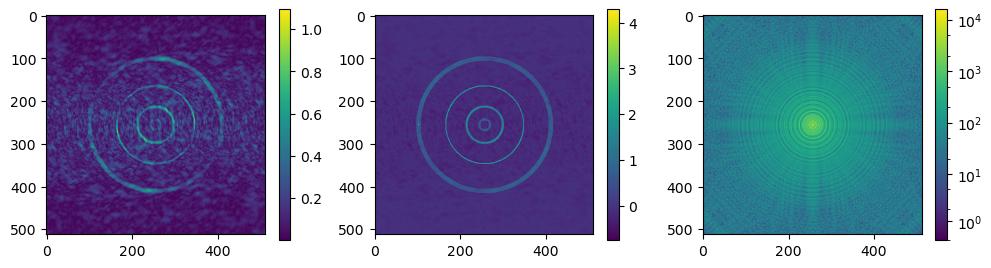

In [286]:
ft_ring = np.fft.fftshift(np.fft.fft2(ring_model))
uv_sampled = ft_ring * hist/hist.sum()
uv_sampled = ft_ring.copy()
uv_sampled[hist == 0] = 0
ift_ring = (np.fft.ifft2(np.fft.fftshift(uv_sampled)))
absiftring = np.abs(ift_ring)
pl.figure(figsize=(12,3))
im = pl.subplot(1,3,1).imshow(absiftring); pl.colorbar(im);
#im = pl.subplot(1,2,2).imshow(ring_model - absiftring/np.median(absiftring[ring_model.astype('bool')]), vmin=-0.07); pl.colorbar(im);
im = pl.subplot(1,3,2).imshow(ring_model - absiftring); pl.colorbar(im);
im = pl.subplot(1,3,3).imshow(np.abs(ft_ring), norm=pl.matplotlib.colors.AsinhNorm()); pl.colorbar(im);

In [173]:
from astropy.convolution import convolve_fft, Gaussian2DKernel

12450.738643527118

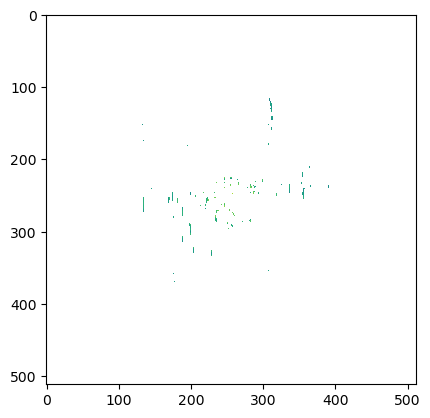

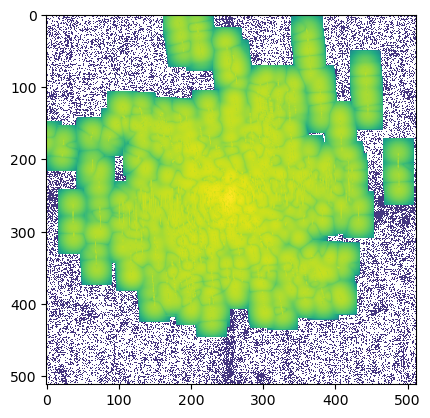

In [287]:
uv_sampled_nans = ft_ring.copy()
uv_sampled_nans[hist == 0] = np.nan

pl.imshow(np.abs(uv_sampled_nans), norm=pl.matplotlib.colors.LogNorm())

kernelsize = 5
kernel = Gaussian2DKernel(kernelsize)
kernel.normalize('peak')
uv_sampled_smoothed_real = convolve_fft(uv_sampled.real, kernel, normalize_kernel=False)
uv_sampled_smoothed_imag = convolve_fft(uv_sampled.imag, kernel, normalize_kernel=False)
uv_sampled_smoothed = uv_sampled_smoothed_real + 1j*uv_sampled_smoothed_imag
uv_sampled_smoothed[np.isnan(uv_sampled_smoothed)] = 0

# don't smooth the inner bit
# uv_sampled_smoothed[rr < 50] = uv_sampled[rr < 50]
uv_sampled_smoothed[hist > 0] = uv_sampled[hist > 0]

pl.figure()
pl.imshow(np.abs(uv_sampled_smoothed), norm=pl.matplotlib.colors.LogNorm())
np.abs(uv_sampled_smoothed).max()

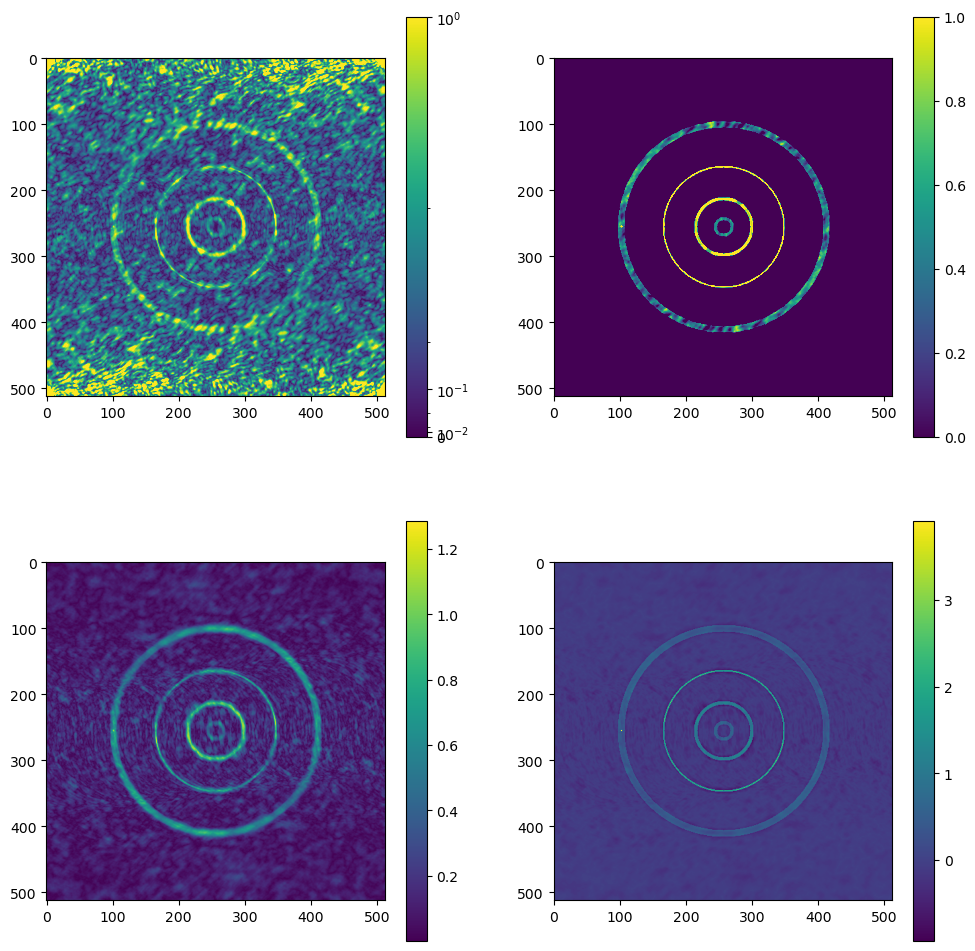

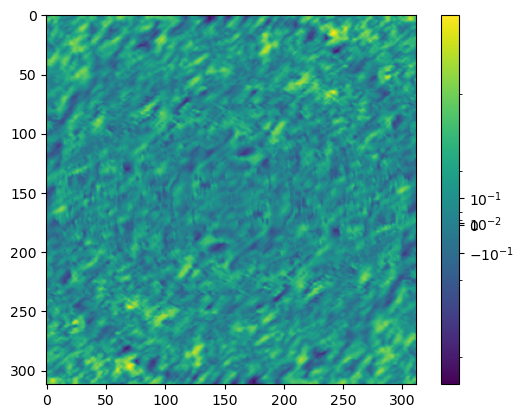

In [198]:
ift_ring_smoothed = np.fft.ifft2(np.fft.fftshift(uv_sampled_smoothed))
absiftring_smoothed = np.abs(ift_ring_smoothed)
pl.figure(figsize=(12,12))
im = pl.subplot(2,2,1).imshow(absiftring_smoothed,  norm=pl.matplotlib.colors.AsinhNorm(vmax=1, vmin=0,)); pl.colorbar(im);
im = pl.subplot(2,2,2).imshow(ring_model - absiftring_smoothed, vmin=0, vmax=1); pl.colorbar(im);
im = pl.subplot(2,2,3).imshow(absiftring); pl.colorbar(im);
im = pl.subplot(2,2,4).imshow(ring_model - absiftring); pl.colorbar(im);
pl.figure()
pl.imshow((absiftring_smoothed - absiftring)[100:-100,100:-100], norm=pl.matplotlib.colors.AsinhNorm()); pl.colorbar();

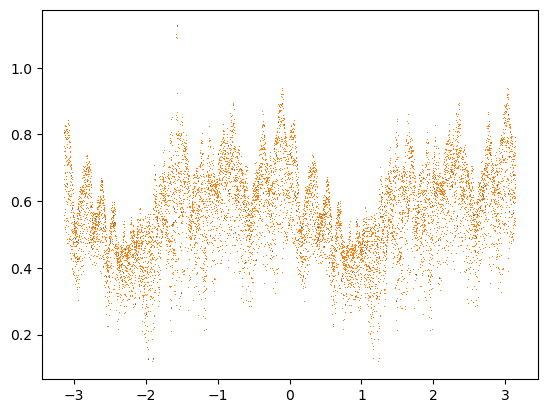

In [177]:
pl.plot(az[(rr > 150) & (rr < 160)], absiftring[(rr > 150) & (rr < 160)], ',')
pl.plot(az[(rr > 150) & (rr < 160)], absiftring_smoothed[(rr > 150) & (rr < 160)], ',')

# Line UV

In [292]:
ms.open('/orange/adamginsburg/orion/2016.1.00165.S/imaging/uid___A002_Xc694dd_X438c.ms')
ms.selectinit(25)
ms.selectchannel(start=100, nchan=1)
ms.selectpolarization('XX')
ms.select({'uvdist': [0.1, 1e10]}) 
uv_line = ms.getdata(['u', 'v', 'data'])
ms.close()

True

In [154]:
uv_line['u'].shape

(1768704,)

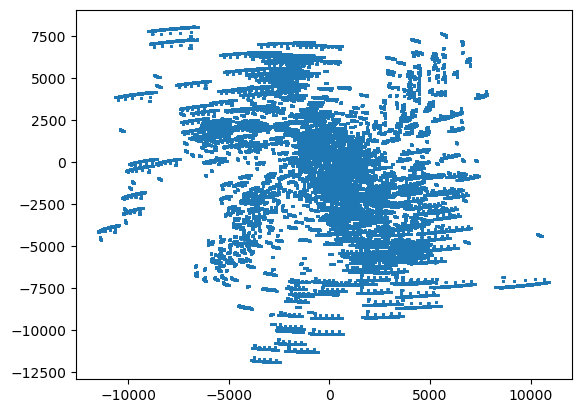

In [126]:
pl.scatter(uv_line['u'], uv_line['v'], s=1)

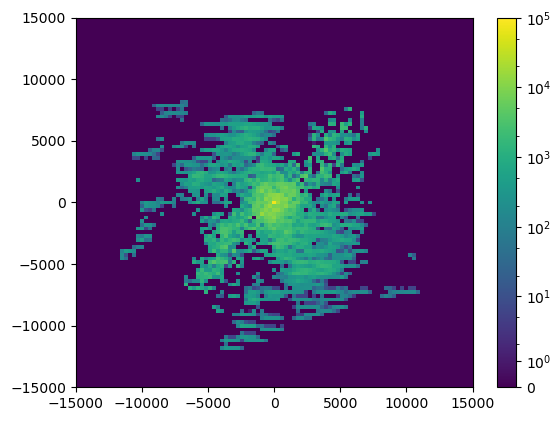

In [125]:
pl.hist2d(uv_line['u'], uv_line['v'],
          norm=pl.matplotlib.colors.AsinhNorm(vmax=1e5, vmin=0),
          bins=[np.linspace(-15000, 15000, 100), np.linspace(-15000, 15000, 100)]);
pl.colorbar();

In [342]:
bins = 1024
uv_minmax = max([np.max(np.abs(uv_line['u'])), np.max(np.abs(uv_line['v']))])
gridded_real, _, _ = np.histogram2d(uv_line['u'], uv_line['v'],
                              weights=uv_line['data'].real.squeeze(),
                              bins=[np.linspace(-uv_minmax, uv_minmax, bins), np.linspace(-uv_minmax, uv_minmax, bins)]);
gridded_imag, _, _ = np.histogram2d(uv_line['u'], uv_line['v'],
                              weights=uv_line['data'].imag.squeeze(),
                              bins=[np.linspace(-uv_minmax, uv_minmax, bins), np.linspace(-uv_minmax, uv_minmax, bins)]);
gridded = gridded_real + gridded_imag*1j

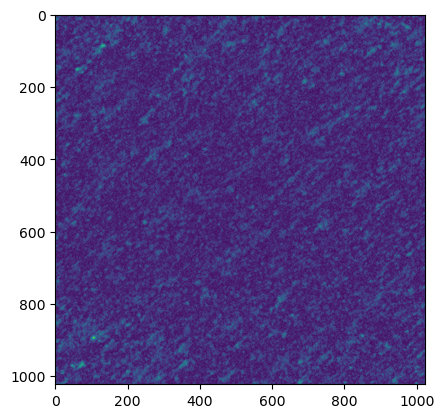

In [351]:
#pl.imshow(gridded_real, norm=pl.matplotlib.colors.AsinhNorm(vmax=0.1))
pl.imshow(np.abs(np.fft.ifft2(np.fft.fftshift(gridded))), norm=pl.matplotlib.colors.AsinhNorm());

## KRISP

In [288]:
from sklearn.gaussian_process import GaussianProcessRegressor      # to run the kernel methods
from sklearn.gaussian_process.kernels import Matern                # for the Matern kernel

In [289]:
kernel = Matern(length_scale=4.4, nu=1.5)

In [326]:
std_deviation = 0.0005

In [327]:
points_list = np.c_[uv_line['u'], uv_line['v']]
vis_points = uv_line['data'].squeeze()

In [328]:
clf_real = GaussianProcessRegressor(kernel=kernel, alpha=std_deviation**2.)
clf_real.fit(points_list[::1000], np.real(vis_points)[::1000])

/blue/adamginsburg/adamginsburg/miniconda3/envs/python310/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=2.5e-07, kernel=Matern(length_scale=4.4, nu=1.5))

In [329]:
clf_imag = GaussianProcessRegressor(kernel=kernel, alpha=std_deviation**2.)  
clf_imag.fit(points_list[::1000], np.imag(vis_points[::1000]))

/blue/adamginsburg/adamginsburg/miniconda3/envs/python310/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=2.5e-07, kernel=Matern(length_scale=4.4, nu=1.5))

In [330]:
dist = (points_list**2).sum(axis=1)**0.5
(dist > 2000).sum()

951539

In [331]:
u = np.linspace(uv_line['u'].min(), uv_line['u'].max(), 512)
v = np.linspace(uv_line['v'].min(), uv_line['v'].max(), 512)
U, V = np.meshgrid(u, v)
prediction_points = np.c_[U.ravel(), V.ravel()]
z_recon_real, z_std_real = clf_real.predict(prediction_points, return_std=True)
z_recon_imag, z_std_imag = clf_imag.predict(prediction_points, return_std=True)
Z_recon = z_recon_real.reshape(U.shape)+z_recon_imag.reshape(U.shape)*1j

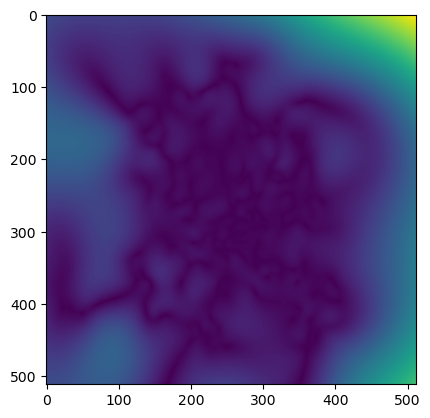

In [332]:
pl.imshow(np.abs(Z_recon))

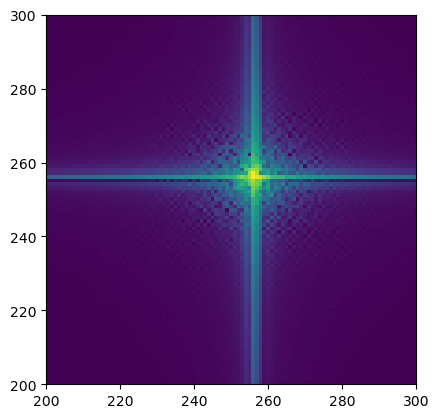

In [336]:
pl.imshow(np.abs(np.fft.fftshift(np.fft.fft2(Z_recon))), norm=pl.matplotlib.colors.AsinhNorm(), )
pl.axis([200,300,200,300]);